# Импорт библиотек для работы с датафреймом и для постороения графиков

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Загрузка данных для создания датафрейма на основе нескольких csv-файлов

In [2]:
tags = pd.read_csv('tags.csv')
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

**Посмотрим на первые 10 строк каждого файла**

In [3]:
tags.head(10)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325


In [4]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [5]:
ratings.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


# Работа с датафреймом movies

**Поиск пропусков**

In [6]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

*Пропуски отсутствуют*

**Превращение жанров в отдельные бинарные колонки (one-hot encoding)**

In [98]:
genres_dummies = movies['genres'].str.get_dummies(sep='|')
genres_dummies.head(10)

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
6,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
7,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


*"1" говорит о том, что фильм относится к жанру в столбце, "0" же, наоборот, означает непринадлежность*

**Объединение movies и таблицы жанров, созданной выше**

In [99]:
movies = pd.concat([movies, genres_dummies], axis=1)
movies.head(10)

,movieId,title,genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,6,Heat (1995),Action|Crime|Thriller,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
6,7,Sabrina (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
7,8,Tom and Huck (1995),Adventure|Children,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,9,Sudden Death (1995),Action,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,10,GoldenEye (1995),Action|Adventure|Thriller,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


**Проверим, если ли одинаковые колонки**

In [52]:
print(movies.columns[movies.columns.duplicated()])

Index(['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
       'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western'],
      dtype='object')


*Одинаковые колонки есть, так что мы удалим дубликаты*

In [100]:
movies = movies.loc[:, ~movies.columns.duplicated()]
movies.head(10)

,movieId,title,genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,6,Heat (1995),Action|Crime|Thriller,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
6,7,Sabrina (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
7,8,Tom and Huck (1995),Adventure|Children,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,9,Sudden Death (1995),Action,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,10,GoldenEye (1995),Action|Adventure|Thriller,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


# Работа с датафреймом ratings

**Убедимся что рейтинг в пределах от "0" до "5"**

In [103]:
min = ratings.rating.min()
print('Минимальный рейтинг равен',min)

Минимальный рейтинг равен 0.5


In [104]:
max = ratings.rating.max()
print('Максимальный рейтинг равен',max)

Максимальный рейтинг равен 5.0


**Узнаем средний рейтинг и вычислим количество оценок каждого фильма по его Id**

In [105]:
ratings_agg = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

In [106]:
ratings_agg.head(10)

,movieId,avg_rating,num_ratings
0,1,3.920930,215
1,2,3.431818,110
2,3,3.259615,52
3,4,2.357143,7
4,5,3.071429,49
5,6,3.946078,102
6,7,3.185185,54
7,8,2.875000,8
8,9,3.125000,16
9,10,3.496212,132


# Соберем два датафрейма в один

In [107]:
movies_enriched = movies.merge(ratings_agg, on='movieId', how='inner')

In [119]:
movies_enriched.head(10)

,movieId,title,genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,num_ratings
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,3.920930,215
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,3.431818,110
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,3.259615,52
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,2.357143,7
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,3.071429,49
5,6,Heat (1995),Action|Crime|Thriller,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,3.946078,102
6,7,Sabrina (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,3.185185,54
7,8,Tom and Huck (1995),Adventure|Children,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,2.875000,8
8,9,Sudden Death (1995),Action,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3.125000,16
9,10,GoldenEye (1995),Action|Adventure|Thriller,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,3.496212,132


# Работа с датафреймом tags

## Очистка и структурирование тегов

Поскольку теги генерируются пользователями вручную, исходные данные содержат шум: теги с опечатками, состоящие только из цифр или знаков препинания, а также слишком короткие теги, не несущие смысловой нагрузки. Для повышения качества объяснений рекомендаций была проведена фильтрация: приведение к нижнему регистру, удаление тегов длиной менее 3 символов и отбор тегов, содержащих исключительно буквенные символы

**Узнаем изначальное количество тегов**

In [109]:
number = len(tags)
print('В датафрейме',number,'тегов')

В датафрейме 3587 тегов


**Приведем к нижнему регистру и уберем пробелы по краям**

In [114]:
tags['tag'] = tags['tag'].str.lower().str.strip()
tags['tag']

0                  funny
1        highly quotable
2           will ferrell
3           boxing story
4                    mma
              ...       
3678           for katie
3679             austere
3680              gun fu
3681    heroic bloodshed
3682    heroic bloodshed
Name: tag, Length: 3587, dtype: object

**Отфильтруем по длине (теги, короче 3 символов удалим, так как они не информативны)**

In [115]:
tags = tags[tags['tag'].str.len() >= 3]
tags.head(10)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,boxing story,1445715207
4,2,89774,mma,1445715200
5,2,89774,tom hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,leonardo dicaprio,1445715051
8,2,106782,martin scorsese,1445715056
9,7,48516,way too long,1169687325


**Удалим теги, содержащие цифры и знаки препинания**

In [116]:
tags = tags[tags['tag'].str.contains(r'[a-zа-яё]', regex=True)]
tags = tags[tags['tag'].str.match(r'^[a-zа-яё\s\-]+$')]
tags.head(10)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,boxing story,1445715207
4,2,89774,mma,1445715200
5,2,89774,tom hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,leonardo dicaprio,1445715051
8,2,106782,martin scorsese,1445715056
9,7,48516,way too long,1169687325


In [81]:
print(f"Стало тегов: {len(tags)}")

Стало тегов: 3587


# Подготовка данных для ML разработчика

## Работа с датафреймом tags

**Группировка по movieId и сбор тегов в список**

In [117]:
tags_agg = tags.groupby('movieId')['tag'].apply(lambda x: list(x.unique())).reset_index()
tags_agg.head(10)

,movieId,tag
0,1,"[pixar, fun]"
1,2,"[fantasy, magic board game, robin williams, game]"
2,3,"[moldy, old]"
3,5,"[pregnancy, remake]"
4,7,[remake]
5,11,"[politics, president]"
6,14,"[politics, president]"
7,16,[mafia]
8,17,[jane austen]
9,21,[hollywood]


**Переименуем колонку для удобства**

In [87]:
tags_agg.rename(columns={'tag': 'top_tags'}, inplace=True)
tags_agg.head(10)

,movieId,top_tags
0,1,"[pixar, fun]"
1,2,"[fantasy, magic board game, robin williams, game]"
2,3,"[moldy, old]"
3,5,"[pregnancy, remake]"
4,7,[remake]
5,11,"[politics, president]"
6,14,"[politics, president]"
7,16,[mafia]
8,17,[jane austen]
9,21,[hollywood]


*Таким образом, у нас есть таблица tags_agg, где для каждого movieId лежит аккуратный список уникальных чистых тегов*

**Агрегация тегов по фильмам**

In [89]:
tags_agg = tags.groupby('movieId')['tag'].apply(
    lambda x: list(x.unique())  
).reset_index()
tags_agg.rename(columns={'tag': 'all_tags'}, inplace=True)
tags_agg['top_tags'] = tags_agg['all_tags'].apply(lambda x: x[:5])
print(f"Фильмов с тегами: {len(tags_agg)}")

Фильмов с тегами: 1547


*Мы снова сгруппировали теги, а также удалили дубликаты тегов и оставили топ-5 тегов для каждого фильма*

In [91]:
tags_agg.head(10)

,movieId,all_tags,top_tags
0,1,"[pixar, fun]","[pixar, fun]"
1,2,"[fantasy, magic board game, robin williams, game]","[fantasy, magic board game, robin williams, game]"
2,3,"[moldy, old]","[moldy, old]"
3,5,"[pregnancy, remake]","[pregnancy, remake]"
4,7,[remake],[remake]
5,11,"[politics, president]","[politics, president]"
6,14,"[politics, president]","[politics, president]"
7,16,[mafia],[mafia]
8,17,[jane austen],[jane austen]
9,21,[hollywood],[hollywood]


## Работа с датафреймом ratings

**Агрегация рейтингов по movieId**

In [97]:
ratings_agg = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),      # Средняя оценка
    num_ratings=('rating', 'count'),    # Количество оценок
    min_rating=('rating', 'min'),
    max_rating=('rating', 'max')
).reset_index()
ratings_agg.head(10)

,movieId,avg_rating,num_ratings,min_rating,max_rating
0,1,3.920930,215,0.5,5.0
1,2,3.431818,110,0.5,5.0
2,3,3.259615,52,0.5,5.0
3,4,2.357143,7,1.0,3.0
4,5,3.071429,49,0.5,5.0
5,6,3.946078,102,1.0,5.0
6,7,3.185185,54,1.0,5.0
7,8,2.875000,8,1.0,5.0
8,9,3.125000,16,1.5,5.0
9,10,3.496212,132,0.5,5.0


In [94]:
print(f"Фильмов с оценками: {len(ratings_agg)}")

Фильмов с оценками: 9724


## Объединение всех данных в одну таблицу

In [141]:
movies_final = movies_enriched.merge(tags_agg, on='movieId', how='left')
movies_final

,movieId,title,genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,num_ratings,all_tags,top_tags
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,1,1,1,1,0,0,...,0,0,0,0,0,0,3.920930,215,"[pixar, fun]","[pixar, fun]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,1,0,1,0,0,0,...,0,0,0,0,0,0,3.431818,110,"[fantasy, magic board game, robin williams, game]","[fantasy, magic board game, robin williams, game]"
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,1,0,0,0,0,3.259615,52,"[moldy, old]","[moldy, old]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,1,0,0,...,0,1,0,0,0,0,2.357143,7,NaN,NaN
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,3.071429,49,"[pregnancy, remake]","[pregnancy, remake]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9685,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,1,0,1,0,1,0,0,...,0,0,0,0,0,0,4.000000,1,NaN,NaN
9686,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,0,0,1,0,1,0,0,...,0,0,0,0,0,0,3.500000,1,NaN,NaN
9687,193585,Flint (2017),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3.500000,1,NaN,NaN
9688,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,1,0,1,0,0,0,0,...,0,0,0,0,0,0,3.500000,1,NaN,NaN


*Заметим, что не все фильмы имеют теги. Поэтому заменим 'Nan' на пустые строки*

In [145]:
df = movies_final
df['all_tags'] = df['all_tags'].apply(
    lambda x: x if isinstance(x, list) else []
)

**Создаем колонку top_tags на основе уже очищенной all_tags**

In [146]:
df['top_tags'] = df['all_tags'].apply(
    lambda x: x[:5] if len(x) > 0 else []
)

In [147]:
df[df['all_tags'].apply(len) == 0].head()

,movieId,title,genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,num_ratings,all_tags,top_tags
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,1,0,0,...,0,1,0,0,0,0,2.357143,7,[],[]
5,6,Heat (1995),Action|Crime|Thriller,1,0,0,0,0,1,0,...,0,0,0,1,0,0,3.946078,102,[],[]
7,8,Tom and Huck (1995),Adventure|Children,0,1,0,1,0,0,0,...,0,0,0,0,0,0,2.875000,8,[],[]
8,9,Sudden Death (1995),Action,1,0,0,0,0,0,0,...,0,0,0,0,0,0,3.125000,16,[],[]
9,10,GoldenEye (1995),Action|Adventure|Thriller,1,1,0,0,0,0,0,...,0,0,0,1,0,0,3.496212,132,[],[]


*Мы заменили NaN на [], чтобы программа по поиску топа фильмов не выдавала ошибок*

# Визуализация данных

**Импорт библиотек для построения графиков**

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

**Настройка стиля**

In [153]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## График 1: Распределение рейтингов

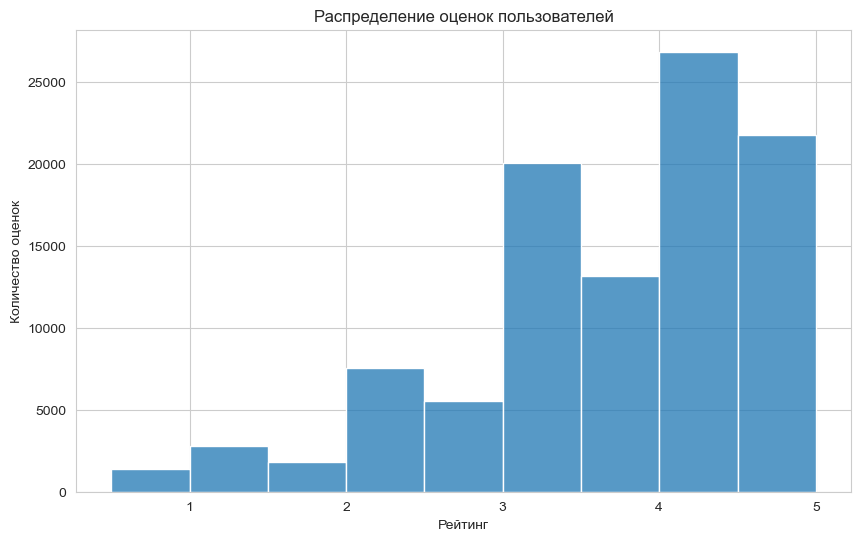

In [154]:
plt.figure()
sns.histplot(ratings['rating'], bins=9, kde=False)
plt.title('Распределение оценок пользователей')
plt.xlabel('Рейтинг')
plt.ylabel('Количество оценок')
plt.savefig('rating_distribution.png', dpi=300)  # Сохрани для отчёта
plt.show()

## График 2: Топ-10 жанров по количеству фильмов

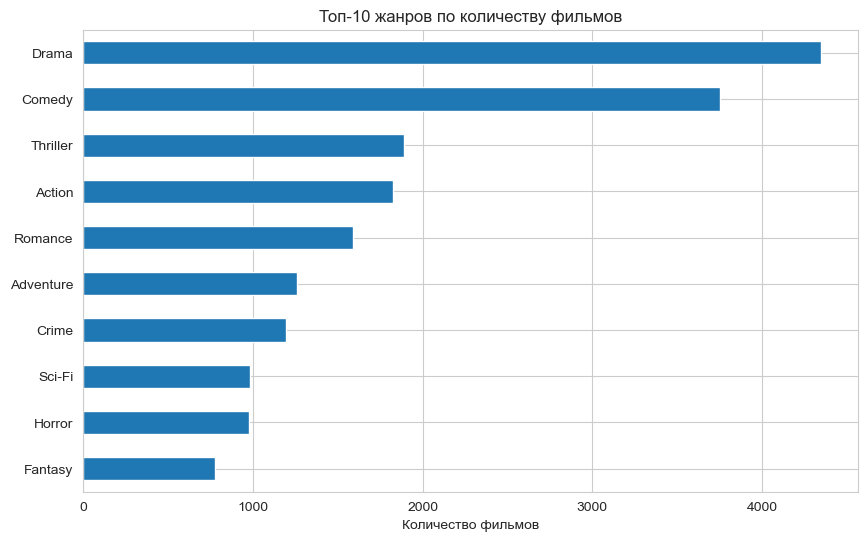

In [155]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Horror', 
              'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
genre_counts = movies_final[genre_cols].sum().sort_values(ascending=True)

plt.figure()
genre_counts.tail(10).plot(kind='barh')
plt.title('Топ-10 жанров по количеству фильмов')
plt.xlabel('Количество фильмов')
plt.savefig('top_genres.png', dpi=300)
plt.show()

## График 3: Зависимость среднего рейтинга от количества оценок

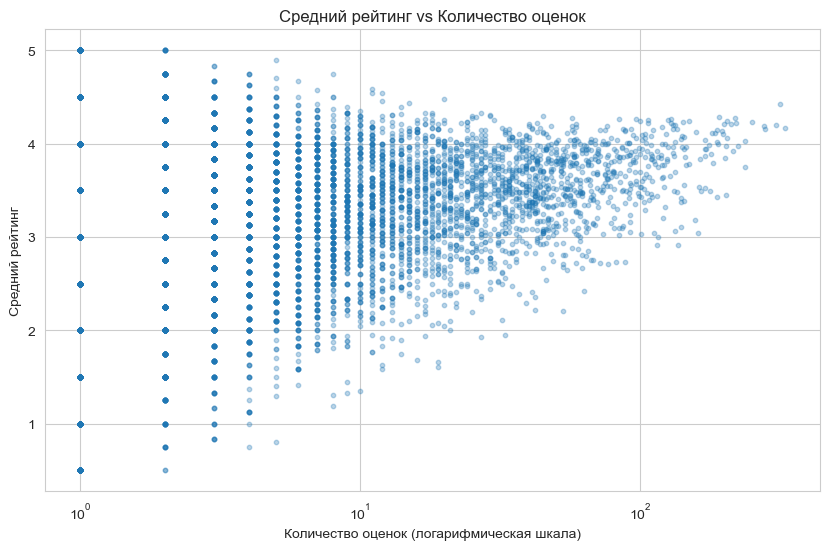

In [156]:
plt.figure()
plt.scatter(ratings_agg['num_ratings'], ratings_agg['avg_rating'], 
            alpha=0.3, s=10)
plt.title('Средний рейтинг vs Количество оценок')
plt.xlabel('Количество оценок (логарифмическая шкала)')
plt.ylabel('Средний рейтинг')
plt.xscale('log')
plt.savefig('rating_vs_count.png', dpi=300)
plt.show()

## График 4: Топ-10 самых популярных фильмов (по числу оценок)

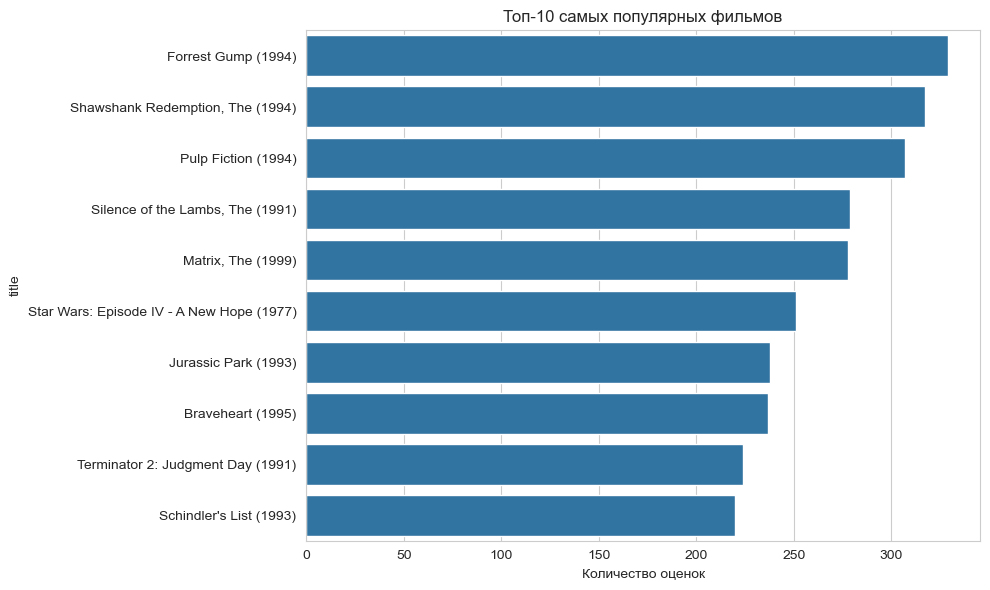

In [157]:
top_movies = movies_final.nlargest(10, 'num_ratings')[['title', 'num_ratings']]

plt.figure()
sns.barplot(data=top_movies, x='num_ratings', y='title')
plt.title('Топ-10 самых популярных фильмов')
plt.xlabel('Количество оценок')
plt.tight_layout()
plt.savefig('top_movies.png', dpi=300)
plt.show()

# Сохранение датафреймов

**Главный датафрейм**

In [159]:
movies_final.to_csv('movies_enriched.csv', index=False)

**Таблица тегов**

In [160]:
tags_agg.to_csv('movie_tags.csv', index=False)

**Статистика рейтингов**

In [161]:
ratings_agg.to_csv('ratings_stats.csv', index=False)